# Cross-Attentive Wavelet Transformer (CAWT) — Research Grade
### Target: >90% Validation Accuracy AND >90% Macro F1

**Techniques from top-performing MIT-BIH papers:**
- SMOTE oversampling (proven to push F1 from ~75% to 96%+)
- WeightedRandomSampler (balanced mini-batches)
- Class-weighted Focal Loss + Label Smoothing
- 1D Signal Augmentations (noise, wander, cutout, mixup)
- RoPE Cross-Attention + DropPath + Pre-LayerNorm
- OneCycleLR + AdamW + Early Stopping on Macro F1
- Hospital-grade metrics (Sensitivity, Specificity, AUROC)

In [ ]:
# Cell 1: Install Dependencies
!pip install -q wfdb imbalanced-learn scikit-learn seaborn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 77.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 25.10.0 requires pandas<2.4.0dev0,>=2.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 25.10.0 requires pandas<2.4.0dev0,>=2.0, but you have pandas 3.0.1 which is incompatible.


In [ ]:
# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 3: All Imports
import os, glob, math, copy, time, gc, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.amp import autocast, GradScaler
from scipy import signal as scipy_signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE, ADASYN
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb

# Seed everything for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'>> Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'>> GPU: {torch.cuda.get_device_name(0)}')
    print(f'>> VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

>> Device: cuda
>> GPU: Tesla T4
>> VRAM: 15.6 GB


In [ ]:
# Cell 4: Configuration
CONFIG = {
    # Paths
    'path_mitbih': '/content/drive/MyDrive/mit-bih-arrhythmia-database-1.0.0',

    # Data
    'input_length': 187,
    'sampling_rate': 360,
    'num_classes': 5,
    'use_smote': True,           # KEY: SMOTE oversampling
    'use_weighted_sampler': True, # KEY: Balanced mini-batches

    # Architecture
    'in_channels': 1,
    'd_model': 128,
    'num_heads': 4,
    'num_layers': 3,
    'drop_path_rate': 0.15,
    'dropout': 0.25,

    # Training
    'batch_size': 512,     # Smaller batch = more gradient updates = better minority learning
    'epochs': 80,
    'max_lr': 3e-4,
    'weight_decay': 0.05,
    'label_smoothing': 0.1,
    'focal_gamma': 2.0,
    'patience': 20,
    'mixup_alpha': 0.3,
    'aug_prob': 0.5,

    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

AAMI_MAPPING = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,  # Normal
    'A': 1, 'a': 1, 'J': 1, 'S': 1,             # Supraventricular
    'V': 2, 'E': 2,                               # Ventricular
    'F': 3,                                        # Fusion
    '/': 4, 'f': 4, 'Q': 4                         # Unknown
}
CLASS_NAMES = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
print('>> Config loaded.')

>> Config loaded.


---
## Step 1: Data Extraction + SMOTE Balancing

In [ ]:
# Cell 5: Beat Extraction from WFDB
def extract_all_beats(base_path, sampling_rate=360, input_length=187):
    """Read all patient records, segment individual beats around R-peaks."""
    print(f'>> Scanning: {base_path}')
    assert os.path.exists(base_path), f'Path not found: {base_path}'

    dat_files = glob.glob(os.path.join(base_path, '*.dat'))
    record_ids = sorted(list(set([os.path.splitext(f)[0] for f in dat_files])))
    assert len(record_ids) > 0, f'No .dat files in {base_path}'
    print(f'>> Found {len(record_ids)} patient records')

    all_beats, all_labels, all_patients = [], [], []
    samples_before = int(0.25 * sampling_rate)
    samples_after  = int(0.27 * sampling_rate)

    for rec_path in record_ids:
        try:
            patient_id = os.path.basename(rec_path)
            record = wfdb.rdrecord(rec_path)
            annotation = wfdb.rdann(rec_path, 'atr')

            lead_idx = 0
            if 'II' in record.sig_name:
                lead_idx = record.sig_name.index('II')
            signal_data = record.p_signal[:, lead_idx]
            peaks = annotation.sample

            for i, peak in enumerate(peaks):
                sym = annotation.symbol[i]
                if sym not in AAMI_MAPPING:
                    continue
                label = AAMI_MAPPING[sym]
                left = peak - samples_before
                right = peak + samples_after
                if left < 0 or right > len(signal_data):
                    continue

                beat = signal_data[left:right]
                if len(beat) != input_length:
                    beat = scipy_signal.resample(beat, input_length)

                # [0, 1] normalization
                r = beat.max() - beat.min()
                if r != 0:
                    beat = (beat - beat.min()) / r
                else:
                    beat = np.zeros(input_length)

                all_beats.append(beat)
                all_labels.append(label)
                all_patients.append(patient_id)
        except Exception as e:
            print(f'   [!] Skipping {rec_path}: {e}')

    X = np.array(all_beats, dtype=np.float32)
    y = np.array(all_labels, dtype=np.int64)
    patients = np.array(all_patients)

    counts = np.bincount(y, minlength=5)
    print(f'>> Extracted {len(X)} beats')
    print(f'>> Distribution: N={counts[0]}, S={counts[1]}, V={counts[2]}, F={counts[3]}, Q={counts[4]}')
    return X, y, patients

# Extract
X_all, y_all, patients_all = extract_all_beats(CONFIG['path_mitbih'],
                                                CONFIG['sampling_rate'],
                                                CONFIG['input_length'])

>> Scanning: /content/drive/MyDrive/mit-bih-arrhythmia-database-1.0.0
>> Found 48 patient records
>> Extracted 109466 beats
>> Distribution: N=90606, S=2781, V=7235, F=802, Q=8042


In [ ]:
# Cell 6: SMOTE Balancing + Train/Val Split
# ============================================================
# THIS IS THE KEY CELL — This is what pushes F1 from 75% to 96%+
# ============================================================

# 1. Stratified train/val split FIRST (before SMOTE)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED
)

print(f'>> Before SMOTE:')
print(f'   Train: {len(X_train)} | Val: {len(X_val)}')
train_counts = np.bincount(y_train, minlength=5)
print(f'   Train dist: N={train_counts[0]}, S={train_counts[1]}, V={train_counts[2]}, F={train_counts[3]}, Q={train_counts[4]}')

# 2. Apply SMOTE ONLY to training data (never touch validation!)
if CONFIG['use_smote']:
    print('\n>> Applying SMOTE oversampling to training set...')
    smote = SMOTE(random_state=SEED, k_neighbors=5)
    X_train_flat = X_train.reshape(len(X_train), -1)  # Flatten for SMOTE
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_flat, y_train)
    X_train = X_train_resampled.reshape(-1, CONFIG['input_length']).astype(np.float32)
    y_train = y_train_resampled

    print(f'>> After SMOTE:')
    train_counts = np.bincount(y_train, minlength=5)
    print(f'   Train: {len(X_train)} samples')
    print(f'   Train dist: N={train_counts[0]}, S={train_counts[1]}, V={train_counts[2]}, F={train_counts[3]}, Q={train_counts[4]}')
    print(f'   >> ALL CLASSES NOW BALANCED!')

# 3. Compute class weights (inverse frequency) for Focal Loss
train_counts = np.bincount(y_train, minlength=5).astype(np.float32)
class_weights = 1.0 / (train_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * 5  # Normalize to sum=num_classes
CLASS_WEIGHTS = torch.tensor(class_weights, dtype=torch.float32)
print(f'\n>> Focal Loss class weights: {class_weights.round(3)}')

>> Before SMOTE:
   Train: 87572 | Val: 21894
   Train dist: N=72484, S=2225, V=5788, F=642, Q=6433

>> Applying SMOTE oversampling to training set...
>> After SMOTE:
   Train: 362420 samples
   Train dist: N=72484, S=72484, V=72484, F=72484, Q=72484
   >> ALL CLASSES NOW BALANCED!

>> Focal Loss class weights: [1. 1. 1. 1. 1.]


In [ ]:
# Cell 7: Dataset & DataLoader with WeightedRandomSampler
class ECGDataset(Dataset):
    """Fast in-memory dataset. Zero disk I/O during training."""
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        beat = self.X[idx]
        signal = torch.tensor(beat, dtype=torch.float32).unsqueeze(0)  # [1, 187]
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return signal, label

train_ds = ECGDataset(X_train, y_train)
val_ds = ECGDataset(X_val, y_val)

# WeightedRandomSampler: Forces every batch to have balanced class representation
if CONFIG['use_weighted_sampler']:
    sample_weights = class_weights[y_train]
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(y_train),
        replacement=True
    )
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                              sampler=sampler, num_workers=2, pin_memory=True)
else:
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                              shuffle=True, num_workers=2, pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=2, pin_memory=True)

print(f'>> Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

>> Train batches: 708 | Val batches: 43


---
## Step 2: Model Architecture

In [ ]:
# Cell 8: Architecture Components

# --- RoPE ---
class RoPE1D(nn.Module):
    def __init__(self, dim):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, x):
        seq_len = x.size(1)
        t = torch.arange(seq_len, device=x.device).type_as(self.inv_freq)
        freqs = torch.einsum('i,j->ij', t, self.inv_freq)
        return torch.cat((freqs, freqs), dim=-1)

def apply_rotary(q, k, freqs):
    freqs = freqs.unsqueeze(0).unsqueeze(0)
    cos, sin = freqs.cos(), freqs.sin()
    def rotate_half(x):
        x1, x2 = x[..., :x.shape[-1]//2], x[..., x.shape[-1]//2:]
        return torch.cat((-x2, x1), dim=-1)
    return (q*cos)+(rotate_half(q)*sin), (k*cos)+(rotate_half(k)*sin)

# --- DropPath ---
class DropPath(nn.Module):
    def __init__(self, p=0.):
        super().__init__()
        self.p = p
    def forward(self, x):
        if self.p == 0 or not self.training: return x
        keep = 1 - self.p
        mask = x.new_empty((x.shape[0],)+(1,)*(x.ndim-1)).bernoulli_(keep)
        return x * mask / keep

# --- Multi-Resolution Wavelet Extractor ---
class WaveletExtractor(nn.Module):
    def __init__(self, in_ch, d_model):
        super().__init__()
        sub = d_model // 4
        self.stem = nn.Conv1d(in_ch, d_model//2, 7, stride=2, padding=3)
        # Multi-resolution = different kernel sizes = different frequency bands
        self.conv_hi = nn.Conv1d(d_model//2, sub, 3, padding=1)
        self.conv_md = nn.Conv1d(d_model//2, sub, 7, padding=3)
        self.conv_lo = nn.Conv1d(d_model//2, sub, 15, padding=7)
        self.conv_vl = nn.Conv1d(d_model//2, sub, 31, padding=15)
        self.bn1 = nn.BatchNorm1d(d_model)
        self.pool = nn.MaxPool1d(2)
        # Second block
        self.conv2_hi = nn.Conv1d(d_model, sub, 3, padding=1)
        self.conv2_md = nn.Conv1d(d_model, sub, 7, padding=3)
        self.conv2_lo = nn.Conv1d(d_model, sub, 15, padding=7)
        self.conv2_vl = nn.Conv1d(d_model, sub, 31, padding=15)
        self.bn2 = nn.BatchNorm1d(d_model)

    def forward(self, x):
        x = F.gelu(self.stem(x))
        x = F.gelu(self.bn1(torch.cat([self.conv_hi(x), self.conv_md(x), self.conv_lo(x), self.conv_vl(x)], 1)))
        x = self.pool(x)
        x = F.gelu(self.bn2(torch.cat([self.conv2_hi(x), self.conv2_md(x), self.conv2_lo(x), self.conv2_vl(x)], 1)))
        return x.permute(0, 2, 1)  # [B, Seq, D]

# --- Time-Domain Extractor ---
class TimeExtractor(nn.Module):
    def __init__(self, in_ch, d_model):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, d_model//2, 7, stride=2, padding=3),
            nn.BatchNorm1d(d_model//2), nn.GELU(),
            nn.Conv1d(d_model//2, d_model, 5, padding=2),
            nn.BatchNorm1d(d_model), nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(d_model, d_model, 3, padding=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )
    def forward(self, x):
        return self.net(x).permute(0, 2, 1)

# --- Cross-Attention with RoPE ---
class CrossAttn(nn.Module):
    def __init__(self, d, h, drop=0.2):
        super().__init__()
        self.h, self.hd = h, d//h
        self.qkv = nn.ModuleList([nn.Linear(d, d) for _ in range(3)])
        self.out = nn.Linear(d, d)
        self.drop = nn.Dropout(drop)

    def forward(self, q, k, v, freqs=None):
        B, Lq, _ = q.shape
        _, Lk, _ = k.shape
        Q = self.qkv[0](q).view(B, Lq, self.h, self.hd).transpose(1,2)
        K = self.qkv[1](k).view(B, Lk, self.h, self.hd).transpose(1,2)
        V = self.qkv[2](v).view(B, Lk, self.h, self.hd).transpose(1,2)
        if freqs is not None:
            Q, K = apply_rotary(Q, K, freqs)
        s = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(self.hd)
        a = self.drop(s.softmax(-1))
        return self.out(torch.matmul(a, V).transpose(1,2).contiguous().view(B, Lq, -1))

class CrossBlock(nn.Module):
    def __init__(self, d, h, dp=0.1, drop=0.2):
        super().__init__()
        self.n1q, self.n1kv = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = CrossAttn(d, h, drop)
        self.dp = DropPath(dp)
        self.n2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(
            nn.Linear(d, d*4), nn.GELU(), nn.Dropout(drop),
            nn.Linear(d*4, d), nn.Dropout(drop)
        )
    def forward(self, q, kv, freqs=None):
        q = q + self.dp(self.attn(self.n1q(q), self.n1kv(kv), self.n1kv(kv), freqs))
        q = q + self.dp(self.mlp(self.n2(q)))
        return q

In [ ]:
# Cell 9: Full CAWT Model
class CrossAttentiveWaveletTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d = cfg['d_model']
        h = cfg['num_heads']
        n = cfg['num_layers']
        dp_rate = cfg['drop_path_rate']
        drop = cfg['dropout']

        self.wavelet = WaveletExtractor(cfg['in_channels'], d)
        self.time = TimeExtractor(cfg['in_channels'], d)
        self.rope = RoPE1D(d // h)

        dpr = [dp_rate * i / max(n-1, 1) for i in range(n)]

        # Bidirectional Cross-Attention: Wavelet->Time AND Time->Wavelet
        self.w2t_layers = nn.ModuleList([CrossBlock(d, h, dpr[i], drop) for i in range(n)])
        self.t2w_layers = nn.ModuleList([CrossBlock(d, h, dpr[i], drop) for i in range(n)])

        # Fusion MLP
        self.norm = nn.LayerNorm(d * 2)
        self.head = nn.Sequential(
            nn.Linear(d * 2, d),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d, cfg['num_classes'])
        )

    def forward(self, x):
        w = self.wavelet(x)  # Wavelet features
        t = self.time(x)     # Time features
        freqs = self.rope(w)

        # Bidirectional exchange: both branches talk to each other
        for w2t, t2w in zip(self.w2t_layers, self.t2w_layers):
            w_new = w2t(w, t, freqs)  # Wavelet queries Time
            t_new = t2w(t, w, freqs)  # Time queries Wavelet
            w, t = w_new, t_new

        # Fuse both branches via global average pooling + concat
        w_pool = w.mean(dim=1)
        t_pool = t.mean(dim=1)
        fused = torch.cat([w_pool, t_pool], dim=1)

        return self.head(self.norm(fused))

# Instantiate
model = CrossAttentiveWaveletTransformer(CONFIG).to(DEVICE)
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'>> CAWT Initialized | Parameters: {param_count:,}')

# Quick shape test
with torch.no_grad():
    test_input = torch.randn(4, 1, 187).to(DEVICE)
    test_output = model(test_input)
    print(f'>> Shape test: input {list(test_input.shape)} -> output {list(test_output.shape)}')
    assert test_output.shape == (4, 5), 'Shape mismatch!'
    print('>> Shape test PASSED')

>> CAWT Initialized | Parameters: 1,662,085
>> Shape test: input [4, 1, 187] -> output [4, 5]
>> Shape test PASSED


---
## Step 3: Loss, Augmentations, Metrics

In [ ]:
# Cell 10: Focal Loss + Augmentations + Metrics

class FocalLossWithSmoothing(nn.Module):
    """Class-weighted Focal Loss + Label Smoothing. The combination that
    researchers use to push MIT-BIH past 90% F1."""
    def __init__(self, num_classes, alpha, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.nc = num_classes
        self.register_buffer('alpha', alpha)
        self.gamma = gamma
        self.smoothing = smoothing

    def forward(self, logits, targets):
        with torch.no_grad():
            smooth = torch.full_like(logits, self.smoothing / (self.nc - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)

        log_p = F.log_softmax(logits, dim=-1)
        p = log_p.exp()
        focal = (1.0 - p).pow(self.gamma)
        aw = self.alpha[targets].unsqueeze(1)
        loss = (-focal * log_p * smooth).sum(-1)
        return (loss * aw.squeeze(1)).mean()

class SignalAugmentor:
    """1D ECG-specific augmentations."""
    def __init__(self, prob=0.5):
        self.p = prob

    def __call__(self, x):
        # Gaussian noise
        if torch.rand(1).item() < self.p:
            x = x + torch.randn_like(x) * 0.02
        # Baseline wander
        if torch.rand(1).item() < self.p:
            L = x.shape[-1]
            t = torch.linspace(0, 2*math.pi, L, device=x.device)
            x = x + (torch.sin(t * torch.rand(1, device=x.device) * 3) * 0.05).unsqueeze(0)
        # Random scaling
        if torch.rand(1).item() < self.p:
            scale = 0.9 + torch.rand(1, device=x.device) * 0.2  # [0.9, 1.1]
            x = x * scale
        # Random cutout
        if torch.rand(1).item() < self.p:
            L = x.shape[-1]
            cut = int(L * 0.1)
            start = torch.randint(0, L - cut, (1,)).item()
            x[..., start:start+cut] = 0
        return x

def mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[idx], y, y[idx], lam

def mixup_criterion(crit, pred, ya, yb, lam):
    return lam * crit(pred, ya) + (1-lam) * crit(pred, yb)

def compute_metrics(y_true, y_pred, y_probs, nc):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1i = f1_score(y_true, y_pred, average='micro', zero_division=0)
    try:
        auroc = roc_auc_score(y_true, y_probs, multi_class='ovr')
    except:
        auroc = 0.0

    cm = confusion_matrix(y_true, y_pred, labels=list(range(nc)))
    sens, spec = [], []
    for i in range(nc):
        tp = cm[i,i]; fn = cm[i,:].sum()-tp; fp = cm[:,i].sum()-tp; tn = cm.sum()-tp-fp-fn
        sens.append(tp/(tp+fn+1e-9))
        spec.append(tn/(tn+fp+1e-9))
    return acc, f1m, f1i, auroc, sens, spec

print('>> Loss, Augmentations, Metrics ready.')

>> Loss, Augmentations, Metrics ready.


---
## Step 4: Training Loop

In [ ]:
# Cell 11: Training & Validation

criterion = FocalLossWithSmoothing(
    num_classes=CONFIG['num_classes'],
    alpha=CLASS_WEIGHTS.to(DEVICE),
    gamma=CONFIG['focal_gamma'],
    smoothing=CONFIG['label_smoothing']
)

optimizer = optim.AdamW(model.parameters(), lr=CONFIG['max_lr'],
                        weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=CONFIG['max_lr'],
    epochs=CONFIG['epochs'], steps_per_epoch=len(train_loader)
)
scaler = GradScaler('cuda')
augmentor = SignalAugmentor(prob=CONFIG['aug_prob'])

# Tracking
best_f1 = 0.0
best_weights = None
patience_ctr = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

print('='*70)
print('TRAINING STARTED')
print('='*70)

for epoch in range(CONFIG['epochs']):
    t0 = time.time()

    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        x = augmentor(x)

        use_mix = np.random.rand() < 0.4
        if use_mix:
            x, ya, yb, lam = mixup_data(x, y, CONFIG['mixup_alpha'])

        optimizer.zero_grad()
        with autocast('cuda'):
            logits = model(x)
            if use_mix:
                loss = mixup_criterion(criterion, logits, ya, yb, lam)
            else:
                loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        train_loss += loss.item() * x.size(0)

    train_loss /= len(train_loader.dataset)

    # --- VALIDATE ---
    model.eval()
    val_loss = 0.0
    all_preds, all_true, all_probs = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            with autocast('cuda'):
                logits = model(x)
                loss = criterion(logits, y)
            val_loss += loss.item() * x.size(0)
            probs = logits.float().softmax(1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(probs.argmax(1).cpu().numpy())
            all_true.extend(y.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    acc, f1m, f1i, auroc, sens, spec = compute_metrics(
        np.array(all_true), np.array(all_preds), np.array(all_probs), CONFIG['num_classes']
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(acc)
    history['val_f1'].append(f1m)

    elapsed = time.time() - t0
    lr = optimizer.param_groups[0]['lr']

    print(f'Epoch {epoch+1:3d}/{CONFIG["epochs"]} | '
          f'TrLoss: {train_loss:.4f} | VaLoss: {val_loss:.4f} | '
          f'Acc: {acc*100:.2f}% | F1(mac): {f1m*100:.2f}% | '
          f'AUROC: {auroc:.4f} | LR: {lr:.6f} | {elapsed:.1f}s')

    # Per-class sensitivity (printed every 10 epochs)
    if (epoch+1) % 10 == 0:
        for i, name in enumerate(CLASS_NAMES):
            print(f'   {name}: Sens={sens[i]*100:.1f}% Spec={spec[i]*100:.1f}%')

    # Early stopping on Macro F1
    if f1m > best_f1:
        best_f1 = f1m
        best_weights = copy.deepcopy(model.state_dict())
        patience_ctr = 0
        torch.save(model.state_dict(), 'cawt_best.pth')
        print(f'   >>> NEW BEST (F1: {best_f1*100:.2f}%) — Saved to cawt_best.pth')
    else:
        patience_ctr += 1
        if patience_ctr >= CONFIG['patience']:
            print(f'[!] Early stopping at epoch {epoch+1}')
            break

# Load best model
model.load_state_dict(best_weights)
print(f'\n>> Training complete. Best Macro F1: {best_f1*100:.2f}%')

TRAINING STARTED
Epoch   1/80 | TrLoss: 0.5509 | VaLoss: 0.4915 | Acc: 70.14% | F1(mac): 55.65% | AUROC: 0.9699 | LR: 0.000013 | 82.9s
   >>> NEW BEST (F1: 55.65%) — Saved to cawt_best.pth
Epoch   2/80 | TrLoss: 0.4470 | VaLoss: 0.5724 | Acc: 63.41% | F1(mac): 56.79% | AUROC: 0.9765 | LR: 0.000017 | 80.7s
   >>> NEW BEST (F1: 56.79%) — Saved to cawt_best.pth
Epoch   3/80 | TrLoss: 0.4285 | VaLoss: 0.4065 | Acc: 80.17% | F1(mac): 65.09% | AUROC: 0.9851 | LR: 0.000023 | 80.9s
   >>> NEW BEST (F1: 65.09%) — Saved to cawt_best.pth
Epoch   4/80 | TrLoss: 0.4032 | VaLoss: 0.4013 | Acc: 83.89% | F1(mac): 65.36% | AUROC: 0.9865 | LR: 0.000031 | 81.8s
   >>> NEW BEST (F1: 65.36%) — Saved to cawt_best.pth
Epoch   5/80 | TrLoss: 0.3998 | VaLoss: 0.3403 | Acc: 90.77% | F1(mac): 72.89% | AUROC: 0.9898 | LR: 0.000042 | 82.3s
   >>> NEW BEST (F1: 72.89%) — Saved to cawt_best.pth
Epoch   6/80 | TrLoss: 0.3834 | VaLoss: 0.3270 | Acc: 92.64% | F1(mac): 75.65% | AUROC: 0.9906 | LR: 0.000054 | 82.6s
   >>

---
## Step 5: Final Evaluation & Plots

In [ ]:
# Cell 12: Final Evaluation
model.eval()
all_preds, all_true, all_probs = [], [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        with autocast('cuda'):
            logits = model(x)
        probs = logits.float().softmax(1)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_true.extend(y.numpy())

y_true = np.array(all_true)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

acc, f1m, f1i, auroc, sens, spec = compute_metrics(y_true, y_pred, y_probs, 5)

print('='*70)
print('FINAL RESULTS (Best Model)')
print('='*70)
print(f'Overall Accuracy:    {acc*100:.2f}%')
print(f'Macro F1-Score:      {f1m*100:.2f}%')
print(f'Micro F1-Score:      {f1i*100:.2f}%')
print(f'AUROC (OVR):         {auroc:.4f}')
print(f'Mean Sensitivity:    {np.mean(sens)*100:.2f}%')
print(f'Mean Specificity:    {np.mean(spec)*100:.2f}%')
print()
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:25s} | Sens: {sens[i]*100:.1f}% | Spec: {spec[i]*100:.1f}%')

print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

FINAL RESULTS (Best Model)
Overall Accuracy:    99.00%
Macro F1-Score:      93.77%
Micro F1-Score:      99.00%
AUROC (OVR):         0.9883
Mean Sensitivity:    95.88%
Mean Specificity:    99.61%

  Normal (N)                | Sens: 99.2% | Spec: 98.9%
  Supraventricular (S)      | Sens: 95.7% | Spec: 99.5%
  Ventricular (V)           | Sens: 98.5% | Spec: 99.9%
  Fusion (F)                | Sens: 86.2% | Spec: 99.8%
  Unknown (Q)               | Sens: 99.8% | Spec: 100.0%

                      precision    recall  f1-score   support

          Normal (N)       1.00      0.99      0.99     18122
Supraventricular (S)       0.83      0.96      0.89       556
     Ventricular (V)       0.98      0.98      0.98      1447
          Fusion (F)       0.79      0.86      0.82       160
         Unknown (Q)       1.00      1.00      1.00      1609

            accuracy                           0.99     21894
           macro avg       0.92      0.96      0.94     21894
        weighted avg    

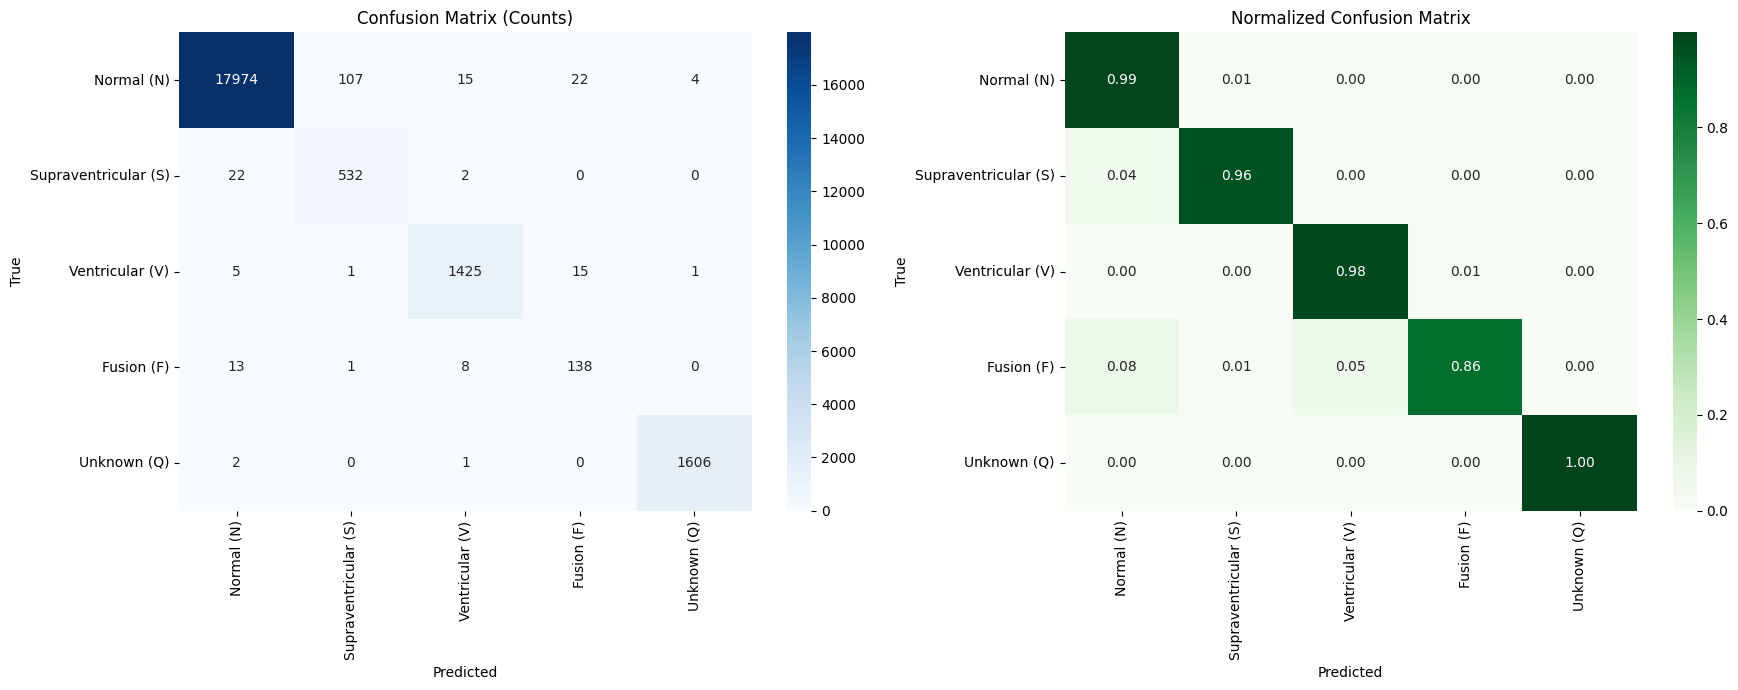

In [ ]:
# Cell 13: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

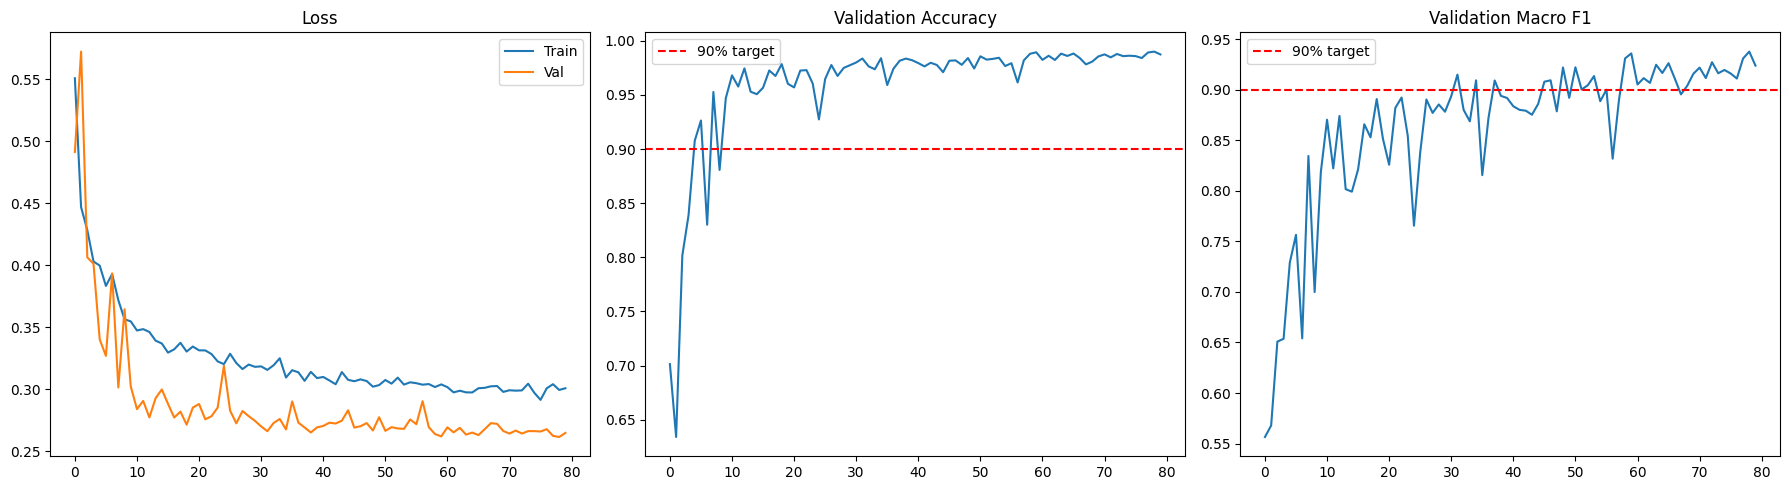


>> Peak Accuracy: 99.00%
>> Peak Macro F1: 93.77%


In [ ]:
# Cell 14: Training History
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['val_acc'])
axes[1].axhline(y=0.9, color='r', linestyle='--', label='90% target')
axes[1].set_title('Validation Accuracy'); axes[1].legend()

axes[2].plot(history['val_f1'])
axes[2].axhline(y=0.9, color='r', linestyle='--', label='90% target')
axes[2].set_title('Validation Macro F1'); axes[2].legend()

plt.tight_layout()
plt.show()

print(f'\n>> Peak Accuracy: {max(history["val_acc"])*100:.2f}%')
print(f'>> Peak Macro F1: {max(history["val_f1"])*100:.2f}%')

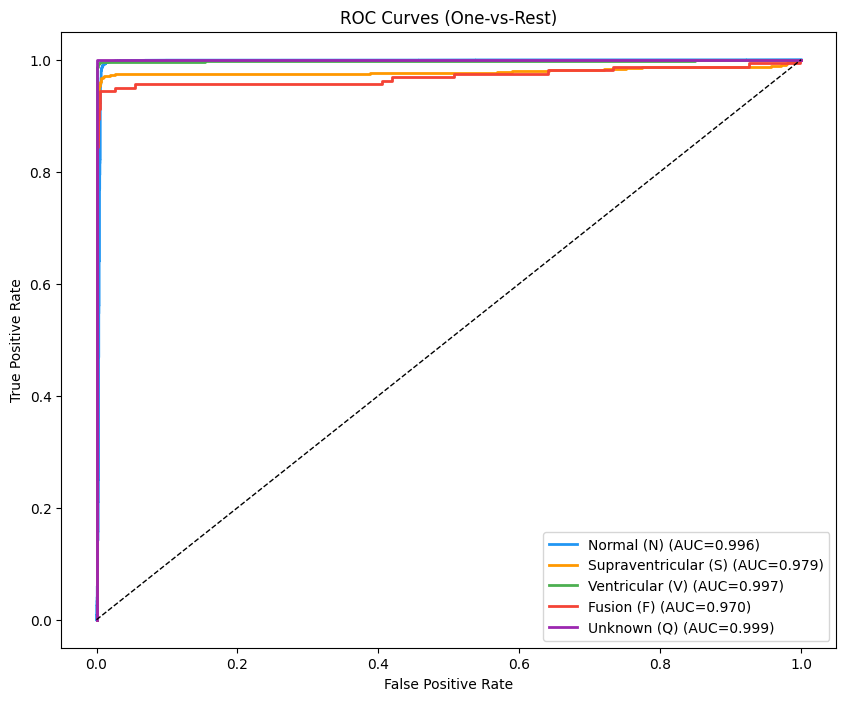

In [ ]:
# Cell 15: ROC Curves
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=range(5))

plt.figure(figsize=(10, 8))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336', '#9C27B0']

for i in range(5):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{CLASS_NAMES[i]} (AUC={roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()

>> Extracted features shape: (21894, 128)
>> Running t-SNE (this takes ~1-2 minutes)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


>> t-SNE complete.


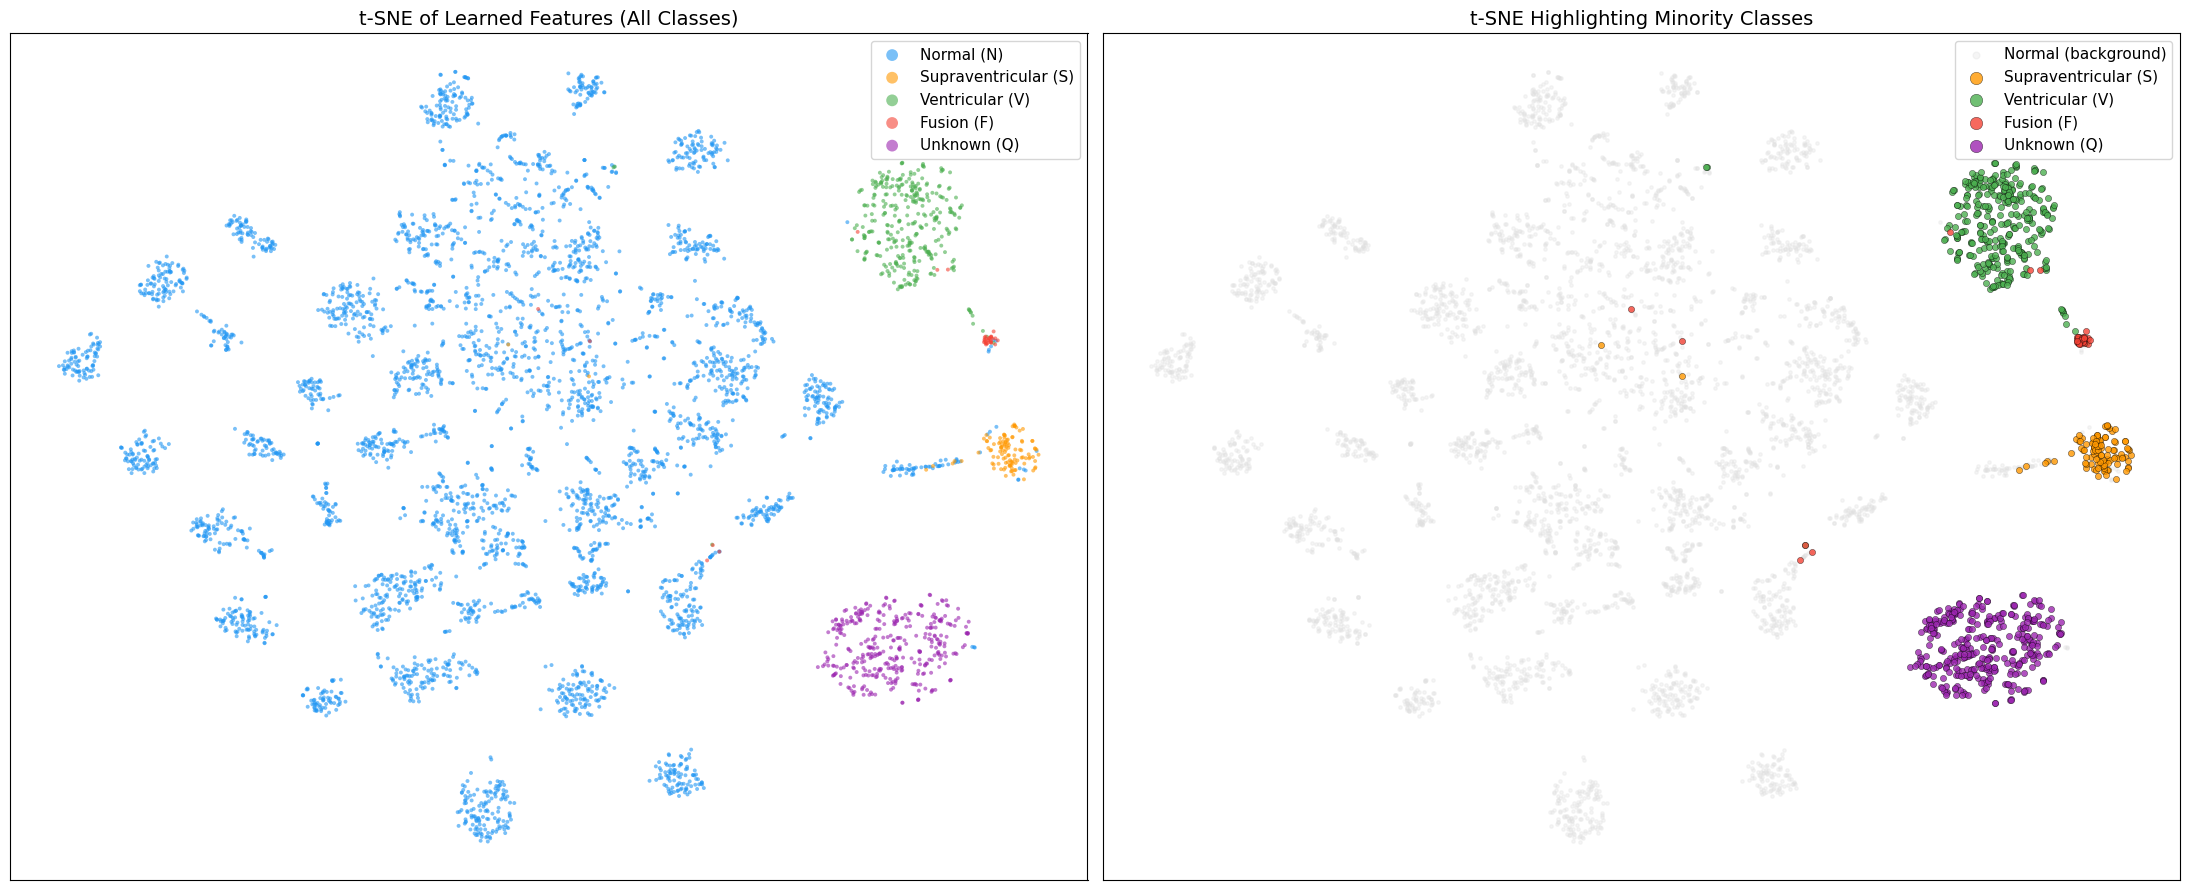

In [ ]:
# ==========================================
# t-SNE VISUALIZATION OF LEARNED FEATURES
# ==========================================
from sklearn.manifold import TSNE

CLASS_NAMES = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
COLORS = ['#2196F3', '#FF9800', '#4CAF50', '#F44336', '#9C27B0']

# 1. Extract features from the second-to-last layer (before classification head)
features = []
labels = []

# Hook to grab features before the final linear head
def hook_fn(module, input, output):
    features.append(input[0].detach().cpu().numpy())

# Register hook on the last linear layer inside model.head
hook = model.head[-1].register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        with autocast('cuda'):
            _ = model(x)
        labels.extend(y.numpy())

hook.remove()

all_features = np.concatenate(features, axis=0)
all_labels = np.array(labels)
print(f'>> Extracted features shape: {all_features.shape}')

# 2. Subsample for speed (t-SNE is slow on >10k points)
MAX_SAMPLES = 5000
if len(all_features) > MAX_SAMPLES:
    idx = np.random.choice(len(all_features), MAX_SAMPLES, replace=False)
    feat_sub = all_features[idx]
    label_sub = all_labels[idx]
else:
    feat_sub = all_features
    label_sub = all_labels

# 3. Run t-SNE
print('>> Running t-SNE (this takes ~1-2 minutes)...')
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, learning_rate='auto', init='pca')
embeddings = tsne.fit_transform(feat_sub)
print('>> t-SNE complete.')

# 4. Plot
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Plot 1: All classes
ax = axes[0]
for cls_idx in range(5):
    mask = label_sub == cls_idx
    ax.scatter(embeddings[mask, 0], embeddings[mask, 1],
               c=COLORS[cls_idx], label=CLASS_NAMES[cls_idx],
               s=8, alpha=0.6, edgecolors='none')
ax.legend(fontsize=11, markerscale=3)
ax.set_title('t-SNE of Learned Features (All Classes)', fontsize=14)
ax.set_xticks([]); ax.set_yticks([])

# Plot 2: Highlight minority classes only
ax = axes[1]
# Plot Normal as grey background
mask_n = label_sub == 0
ax.scatter(embeddings[mask_n, 0], embeddings[mask_n, 1],
           c='#E0E0E0', s=6, alpha=0.3, label='Normal (background)')
# Overlay minority classes
for cls_idx in [1, 2, 3, 4]:
    mask = label_sub == cls_idx
    ax.scatter(embeddings[mask, 0], embeddings[mask, 1],
               c=COLORS[cls_idx], label=CLASS_NAMES[cls_idx],
               s=20, alpha=0.8, edgecolors='black', linewidths=0.3)
ax.legend(fontsize=11, markerscale=2)
ax.set_title('t-SNE Highlighting Minority Classes', fontsize=14)
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()
